# Dataset sanity check
Import `dataset.py`, run a few samples through the eval + train pipelines, overlay masks on images.

In [1]:
import os, sys
for _p in ('.', 'segmentation_model'):  # run from repo root or from segmentation_model/
    if os.path.isdir(os.path.join(_p, 'networks')):
        sys.path.insert(0, os.path.abspath(_p)); break
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import dataset as D

names = D.class_names()
print(len(D.list_pairs('train')), 'train /', len(D.list_pairs('val')), 'val /', len(D.list_pairs('test')), 'test')
names

4092 train / 472 val / 436 test


['background',
 'Tooth',
 'Alveolar Bone (AB)',
 'Root Canal Filling (RCF)',
 'Denture Crown (DC)',
 'Implant (IM)',
 'Dental Fillings (DF)',
 'Pulp',
 'Orthodontic Devices (OD)',
 'Apical Periodontitis (AP)']

In [2]:
# 10-class discrete colormap (0 = background = transparent when overlaid)
cmap = ListedColormap(plt.cm.tab10(np.arange(D.NUM_CLASSES)))

def show(sample, title=''):
    img = sample['image'].numpy().transpose(1, 2, 0)   # CHW -> HWC
    lbl = sample['label'].numpy()[0]                    # 1HW -> HW
    present = sorted(int(c) for c in np.unique(lbl))
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img); ax[0].set_title(f'{title} image {img.shape}')
    ax[1].imshow(lbl, cmap=cmap, vmin=0, vmax=D.NUM_CLASSES - 1); ax[1].set_title('label')
    ax[2].imshow(img)
    ax[2].imshow(np.ma.masked_where(lbl == 0, lbl), cmap=cmap, vmin=0, vmax=D.NUM_CLASSES - 1, alpha=0.5)
    ax[2].set_title('overlay')
    for a in ax: a.axis('off')
    print(title, 'img range', round(float(img.min()), 3), round(float(img.max()), 3),
          '| classes', [names[c] for c in present])
    plt.tight_layout(); plt.show()

## Eval pipeline (letterboxed 512, no aug)

eval img range 0.0 0.993 | classes ['background', 'Tooth', 'Alveolar Bone (AB)', 'Dental Fillings (DF)', 'Pulp']


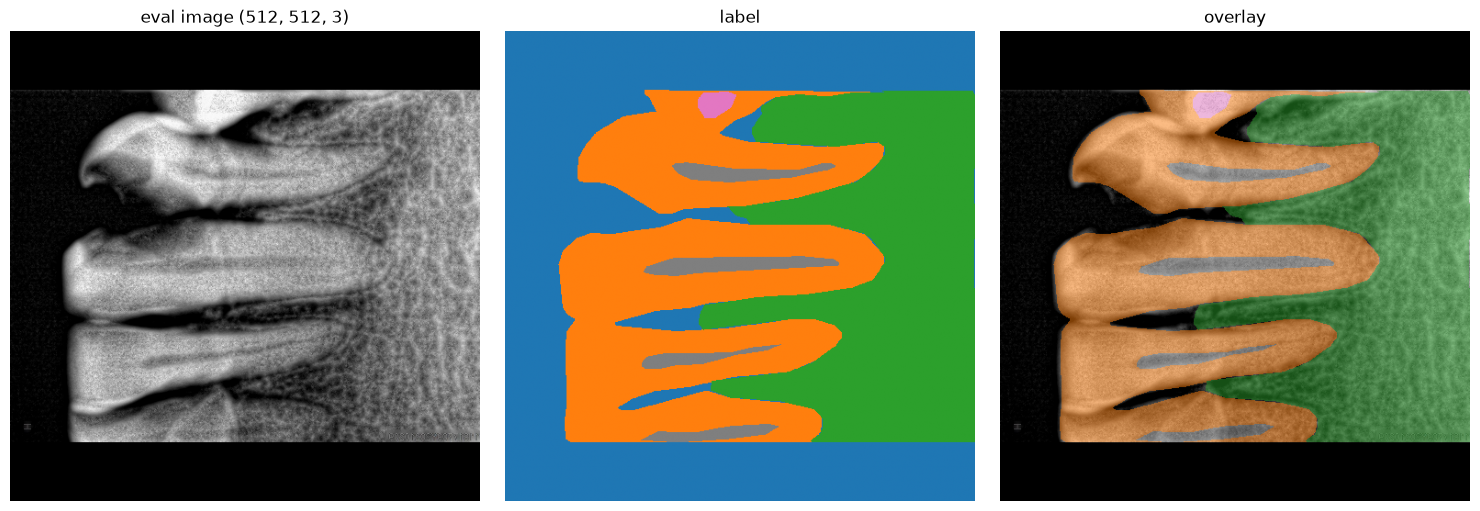

eval img range 0.0 1.0 | classes ['background', 'Tooth', 'Alveolar Bone (AB)', 'Pulp']


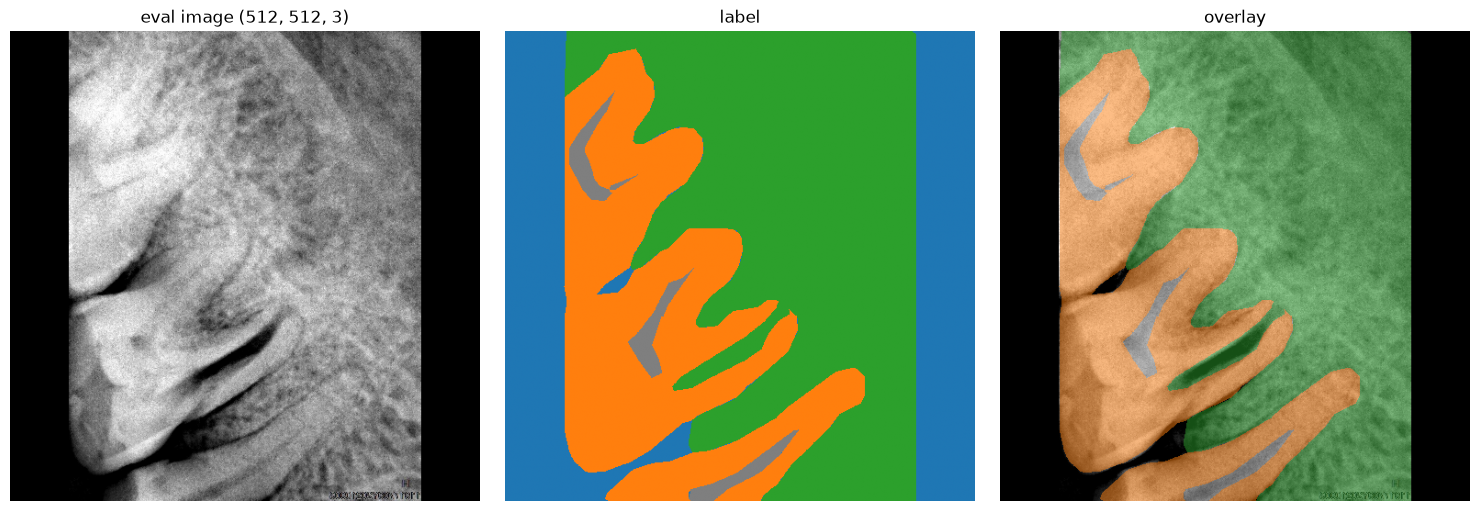

eval img range 0.0 0.959 | classes ['background', 'Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Pulp', 'Apical Periodontitis (AP)']


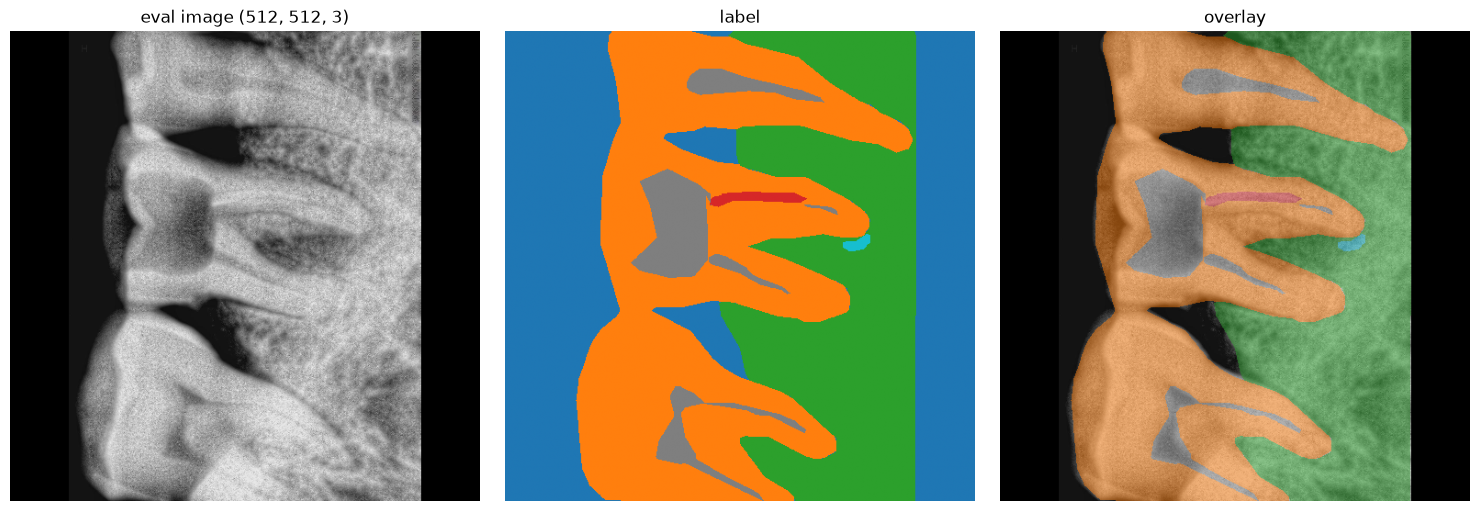

eval img range 0.0 1.0 | classes ['background', 'Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Dental Fillings (DF)', 'Pulp', 'Apical Periodontitis (AP)']


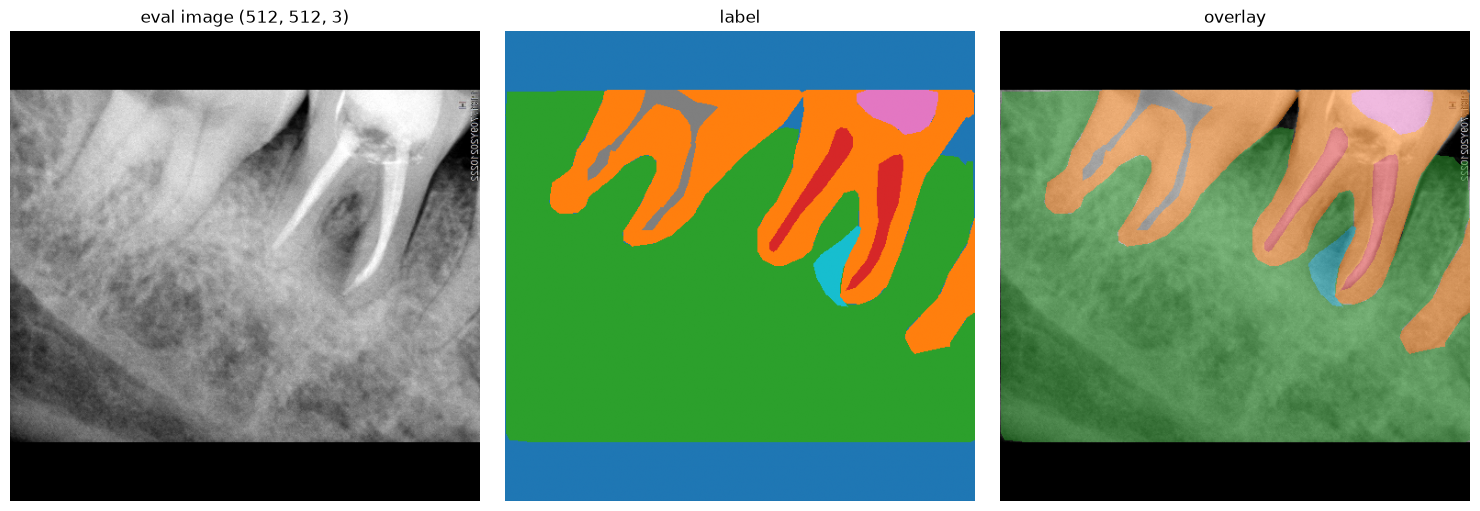

In [3]:
pairs = D.list_pairs('val', limit=4)
for p in pairs:
    show(D.eval_transforms(dict(p)), 'eval')

## Train pipeline (random 256 crop + aug) - run twice to see randomness

train draw 0 img range 0.0 0.717 | classes ['background', 'Tooth', 'Alveolar Bone (AB)', 'Dental Fillings (DF)']


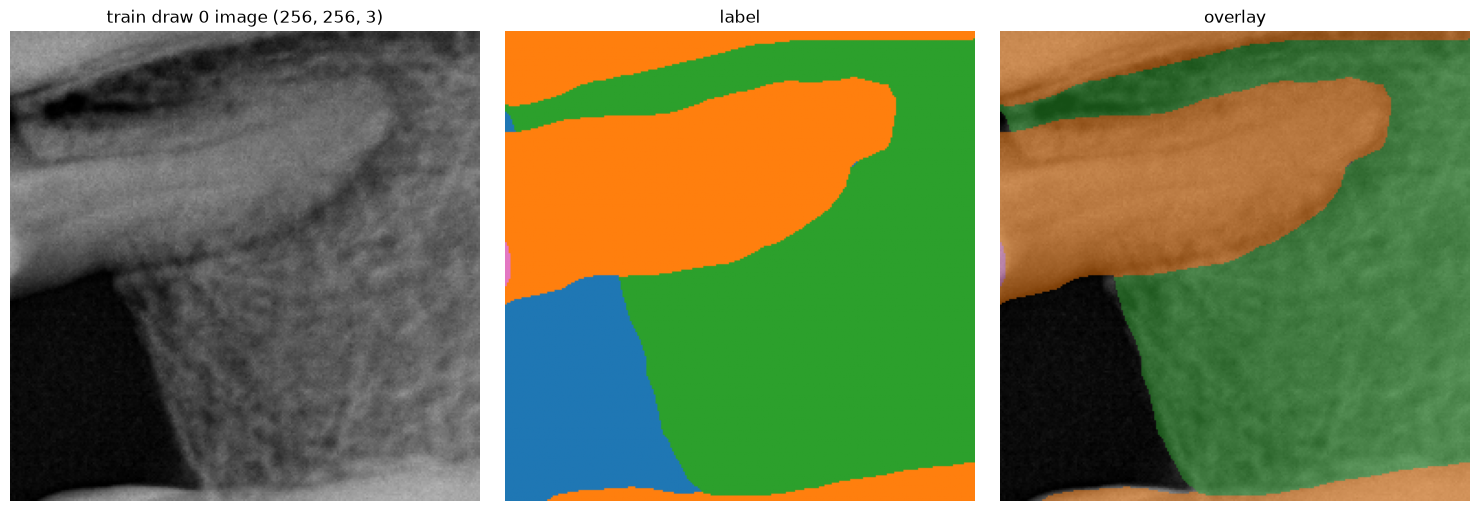

train draw 1 img range 0.0 0.95 | classes ['background', 'Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Dental Fillings (DF)']


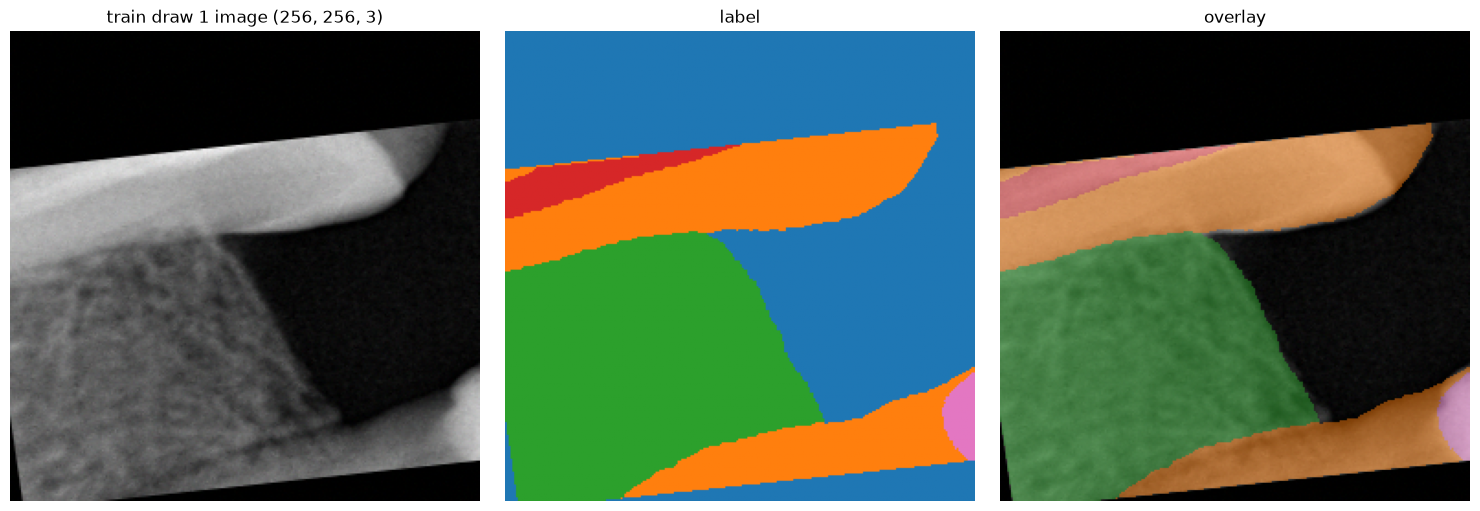

train draw 2 img range 0.0 0.982 | classes ['background', 'Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Dental Fillings (DF)']


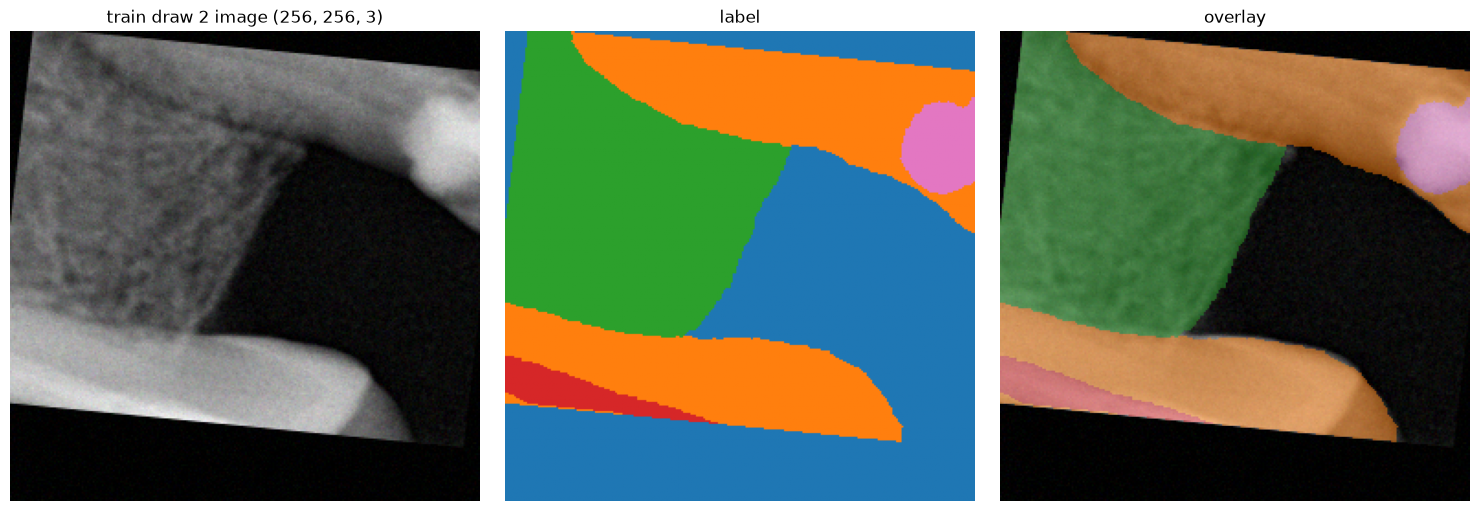

train draw 3 img range 0.0 0.869 | classes ['background', 'Tooth', 'Alveolar Bone (AB)', 'Dental Fillings (DF)', 'Pulp']


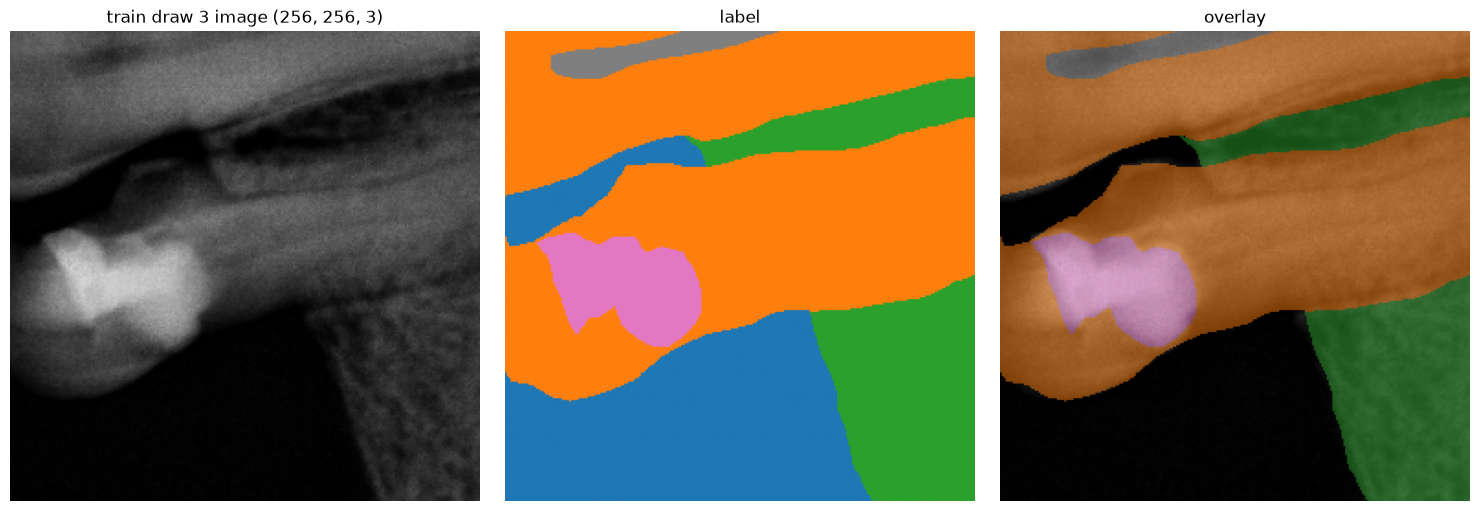

In [4]:
p = D.list_pairs('train', limit=1)[0]
for i in range(4):
    show(D.train_transforms(dict(p)), f'train draw {i}')